# Flight Delay Prediction - Main Analysis

**Objective**: Predict arrival delay (`ARRIVAL_DELAY`) for US commercial flights (2015).

**Two-Stage Approach**:
1. **Stage 1 (Classification)**: Predict whether a flight will have delay >15 minutes
2. **Stage 2 (Regression)**: Estimate the delay magnitude for flights classified as "delayed"

In [134]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve
)
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

pd.set_option('display.max_columns', 50)
np.random.seed(42)
print("Imports completed")

Imports completed


---
## 1. Dataset and Data Loading

In [135]:
DATA_DIR = os.path.join(os.getcwd(), "data")
flights_raw = pd.read_csv(os.path.join(DATA_DIR, "flights.csv"), low_memory=False)
airports = pd.read_csv(os.path.join(DATA_DIR, "airports.csv"))
airlines = pd.read_csv(os.path.join(DATA_DIR, "airlines.csv"))

print(f"Flights: {flights_raw.shape}")
print(f"Airports: {airports.shape}")
print(f"Airlines: {airlines.shape}")

Flights: (5819079, 31)
Airports: (322, 7)
Airlines: (14, 2)


---
## 2. EDA

In [136]:
print("Colonne airports")
print(airports.columns.tolist())
print("Prime righe:")
airports.head()

Colonne airports
['IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'COUNTRY', 'LATITUDE', 'LONGITUDE']
Prime righe:


,IATA_CODE,AIRPORT,CITY,STATE,COUNTRY,LATITUDE,LONGITUDE
0,ABE,Lehigh Valley International Airport,Allentown,PA,USA,40.65236,-75.44040
1,ABI,Abilene Regional Airport,Abilene,TX,USA,32.41132,-99.68190
2,ABQ,Albuquerque International Sunport,Albuquerque,NM,USA,35.04022,-106.60919
3,ABR,Aberdeen Regional Airport,Aberdeen,SD,USA,45.44906,-98.42183
4,ABY,Southwest Georgia Regional Airport,Albany,GA,USA,31.53552,-84.19447


In [137]:
print("Colonne airlines")
print(airlines.columns.tolist())
print("Prime righe:")
airlines.head()

Colonne airlines
['IATA_CODE', 'AIRLINE']
Prime righe:


,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways


In [138]:
print("Colonne flights:")
print(flights_raw.columns.tolist())
print("Prime righe:")
flights_raw.head()

Colonne flights:
['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'AIRLINE', 'FLIGHT_NUMBER', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'DISTANCE', 'WHEELS_ON', 'TAXI_IN', 'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
Prime righe:


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,2354.0,-11.0,21.0,15.0,205.0,194.0,169.0,1448,404.0,4.0,430,408.0,-22.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,2.0,-8.0,12.0,14.0,280.0,279.0,263.0,2330,737.0,4.0,750,741.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,18.0,-2.0,16.0,34.0,286.0,293.0,266.0,2296,800.0,11.0,806,811.0,5.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,15.0,-5.0,15.0,30.0,285.0,281.0,258.0,2342,748.0,8.0,805,756.0,-9.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,24.0,-1.0,11.0,35.0,235.0,215.0,199.0,1448,254.0,5.0,320,259.0,-21.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [139]:
missing = flights_raw.isna().sum()
missing_pct = (missing / len(flights_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_count', ascending=False)
print("Missing values:")
print(missing_df[missing_df['missing_count'] > 0])

Missing values:
                     missing_count  missing_pct
CANCELLATION_REASON        5729195        98.46
LATE_AIRCRAFT_DELAY        4755640        81.72
WEATHER_DELAY              4755640        81.72
AIRLINE_DELAY              4755640        81.72
AIR_SYSTEM_DELAY           4755640        81.72
SECURITY_DELAY             4755640        81.72
ELAPSED_TIME                105071         1.81
AIR_TIME                    105071         1.81
ARRIVAL_DELAY               105071         1.81
WHEELS_ON                    92513         1.59
TAXI_IN                      92513         1.59
ARRIVAL_TIME                 92513         1.59
WHEELS_OFF                   89047         1.53
TAXI_OUT                     89047         1.53
DEPARTURE_TIME               86153         1.48
DEPARTURE_DELAY              86153         1.48
TAIL_NUMBER                  14721         0.25
SCHEDULED_TIME                   6         0.00


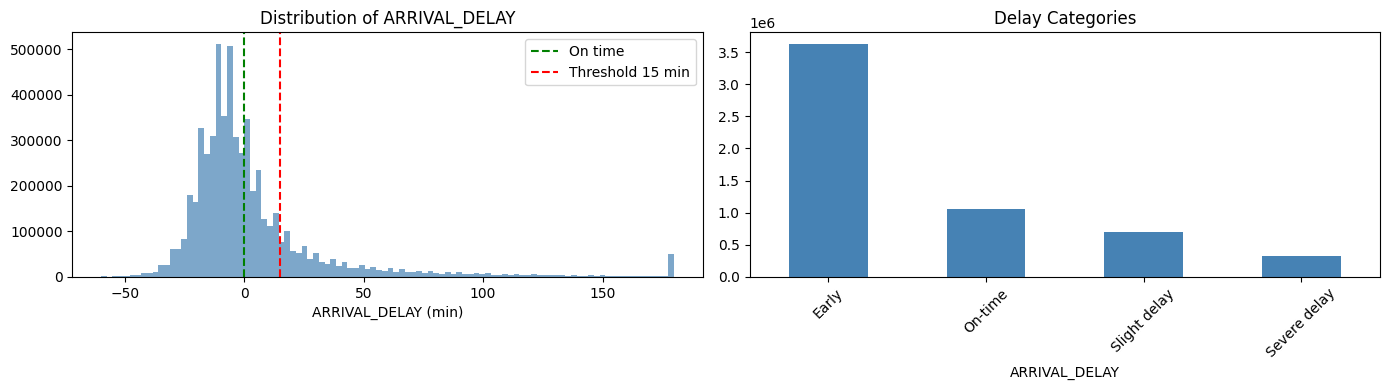

Percentage of flights with delay >15 min: 17.9%


In [140]:
# Filter for analysis
flights_eda = flights_raw[(flights_raw['CANCELLED'] == 0) & (flights_raw['ARRIVAL_DELAY'].notna())].copy()
flights_eda['DEP_HOUR'] = (flights_eda['SCHEDULED_DEPARTURE'] // 100) %24
flights_eda['ARR_HOUR'] = (flights_eda['SCHEDULED_ARRIVAL'] // 100) % 24

# Target distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(flights_eda['ARRIVAL_DELAY'].clip(-60, 180), bins=100, color='steelblue', alpha=0.7)
axes[0].axvline(0, color='green', linestyle='--', label='On time')
axes[0].axvline(15, color='red', linestyle='--', label='Threshold 15 min')
axes[0].set_xlabel('ARRIVAL_DELAY (min)')
axes[0].set_title('Distribution of ARRIVAL_DELAY')
axes[0].legend()

delay_cat = pd.cut(flights_eda['ARRIVAL_DELAY'], bins=[-np.inf, 0, 15, 60, np.inf],
                   labels=['Early', 'On-time', 'Slight delay', 'Severe delay'])
delay_cat.value_counts().plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Delay Categories')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

pct_delayed = (flights_eda['ARRIVAL_DELAY'] > 15).mean() * 100
print(f"Percentage of flights with delay >15 min: {pct_delayed:.1f}%")

### 2.1 Delays by DEPARTURE HOUR

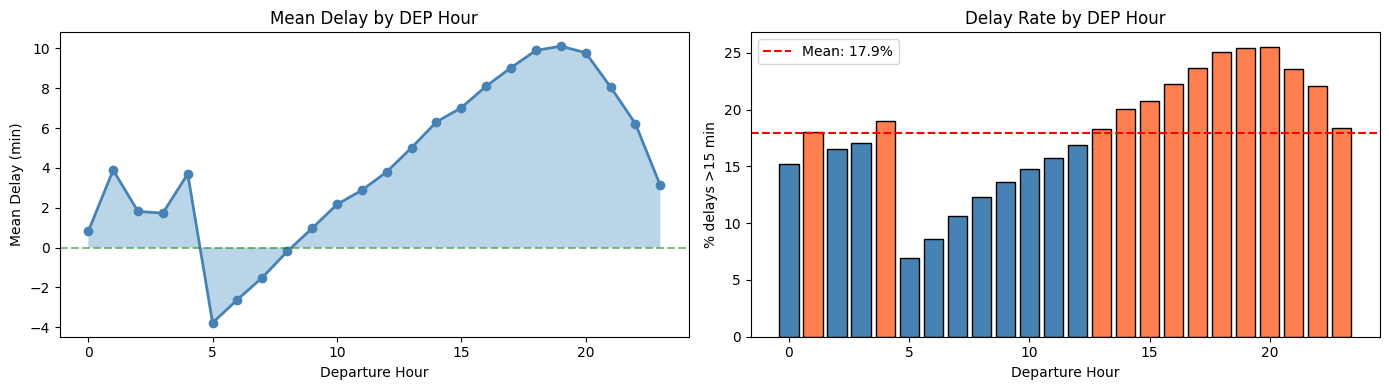

OBSERVATION: Delays increase throughout the day (operational accumulation)


In [141]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Mean delay by departure hour
hourly_delay = flights_eda.groupby('DEP_HOUR')['ARRIVAL_DELAY'].mean()
axes[0].plot(hourly_delay.index, hourly_delay.values, marker='o', color='steelblue', linewidth=2)
axes[0].fill_between(hourly_delay.index, hourly_delay.values, alpha=0.3)
axes[0].set_xlabel('Departure Hour')
axes[0].set_ylabel('Mean Delay (min)')
axes[0].set_title('Mean Delay by DEP Hour')
axes[0].axhline(0, color='green', linestyle='--', alpha=0.5)

# Delay rate >15 by departure hour
hourly_late = flights_eda.groupby('DEP_HOUR').apply(lambda x: (x['ARRIVAL_DELAY'] > 15).mean() * 100)
colors = ['coral' if x > hourly_late.mean() else 'steelblue' for x in hourly_late.values]
axes[1].bar(hourly_late.index, hourly_late.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Departure Hour')
axes[1].set_ylabel('% delays >15 min')
axes[1].set_title('Delay Rate by DEP Hour')
axes[1].axhline(hourly_late.mean(), color='red', linestyle='--', label=f'Mean: {hourly_late.mean():.1f}%')
axes[1].legend()

plt.tight_layout()
plt.show()
print("OBSERVATION: Delays increase throughout the day (operational accumulation)")

### 2.1b Delays by ARRIVAL HOUR

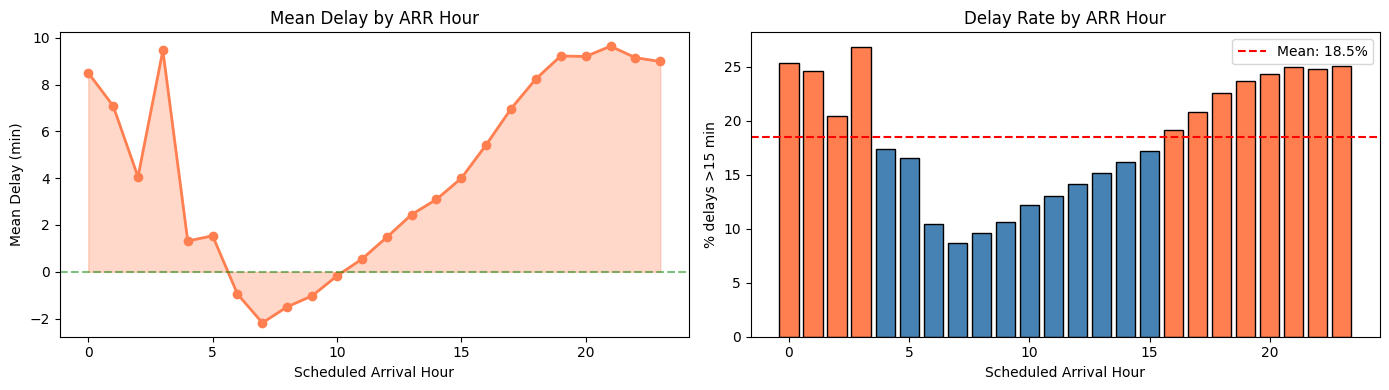

OBSERVATION: ARR hour shows similar pattern to DEP hour - both capture operational congestion


In [142]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Mean delay by arrival hour
arr_hourly_delay = flights_eda.groupby('ARR_HOUR')['ARRIVAL_DELAY'].mean()
axes[0].plot(arr_hourly_delay.index, arr_hourly_delay.values, marker='o', color='coral', linewidth=2)
axes[0].fill_between(arr_hourly_delay.index, arr_hourly_delay.values, alpha=0.3, color='coral')
axes[0].set_xlabel('Scheduled Arrival Hour')
axes[0].set_ylabel('Mean Delay (min)')
axes[0].set_title('Mean Delay by ARR Hour')
axes[0].axhline(0, color='green', linestyle='--', alpha=0.5)

# Delay rate >15 by arrival hour
arr_hourly_late = flights_eda.groupby('ARR_HOUR').apply(lambda x: (x['ARRIVAL_DELAY'] > 15).mean() * 100)
colors = ['coral' if x > arr_hourly_late.mean() else 'steelblue' for x in arr_hourly_late.values]
axes[1].bar(arr_hourly_late.index, arr_hourly_late.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Scheduled Arrival Hour')
axes[1].set_ylabel('% delays >15 min')
axes[1].set_title('Delay Rate by ARR Hour')
axes[1].axhline(arr_hourly_late.mean(), color='red', linestyle='--', label=f'Mean: {arr_hourly_late.mean():.1f}%')
axes[1].legend()

plt.tight_layout()
plt.show()
print("OBSERVATION: ARR hour shows similar pattern to DEP hour - both capture operational congestion")

### 2.2 Delays by AIRLINE

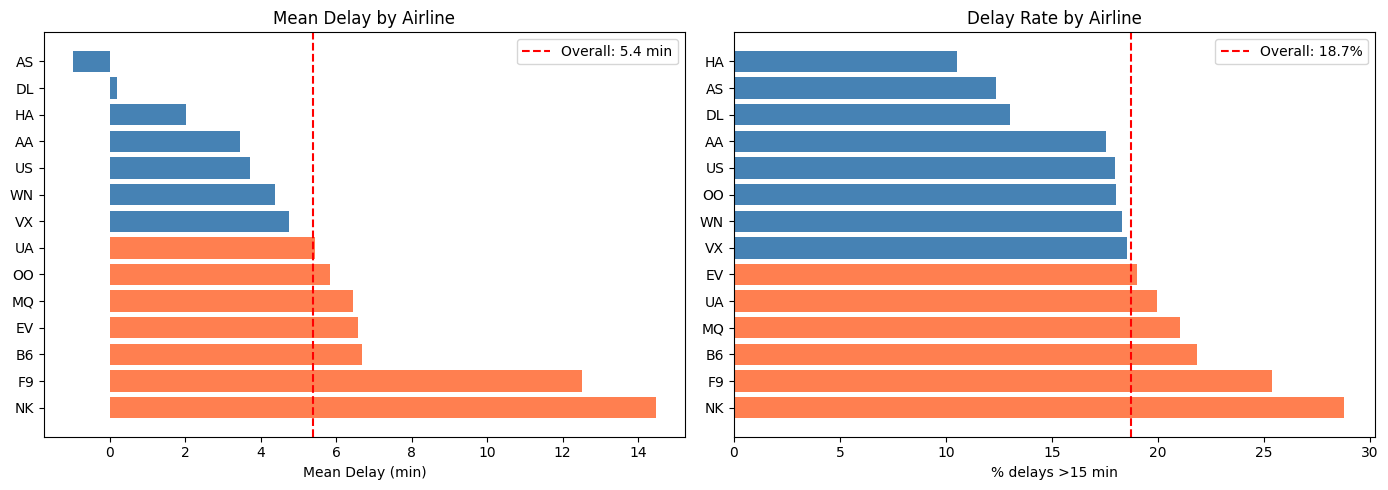

OBSERVATION: Strong variability between airlines


In [143]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

airline_delay = flights_eda.groupby('AIRLINE')['ARRIVAL_DELAY'].mean().sort_values(ascending=False)
colors = ['coral' if x > airline_delay.mean() else 'steelblue' for x in airline_delay.values]
axes[0].barh(airline_delay.index, airline_delay.values, color=colors)
axes[0].set_xlabel('Mean Delay (min)')
axes[0].set_title('Mean Delay by Airline')
axes[0].axvline(airline_delay.mean(), color='red', linestyle='--', label=f'Overall: {airline_delay.mean():.1f} min')
axes[0].legend()

airline_rate = flights_eda.groupby('AIRLINE').apply(lambda x: (x['ARRIVAL_DELAY'] > 15).mean() * 100).sort_values(ascending=False)
colors = ['coral' if x > airline_rate.mean() else 'steelblue' for x in airline_rate.values]
axes[1].barh(airline_rate.index, airline_rate.values, color=colors)
axes[1].set_xlabel('% delays >15 min')
axes[1].set_title('Delay Rate by Airline')
axes[1].axvline(airline_rate.mean(), color='red', linestyle='--', label=f'Overall: {airline_rate.mean():.1f}%')
axes[1].legend()

plt.tight_layout()
plt.show()
print("OBSERVATION: Strong variability between airlines")

### 2.2b Delays by HOUR

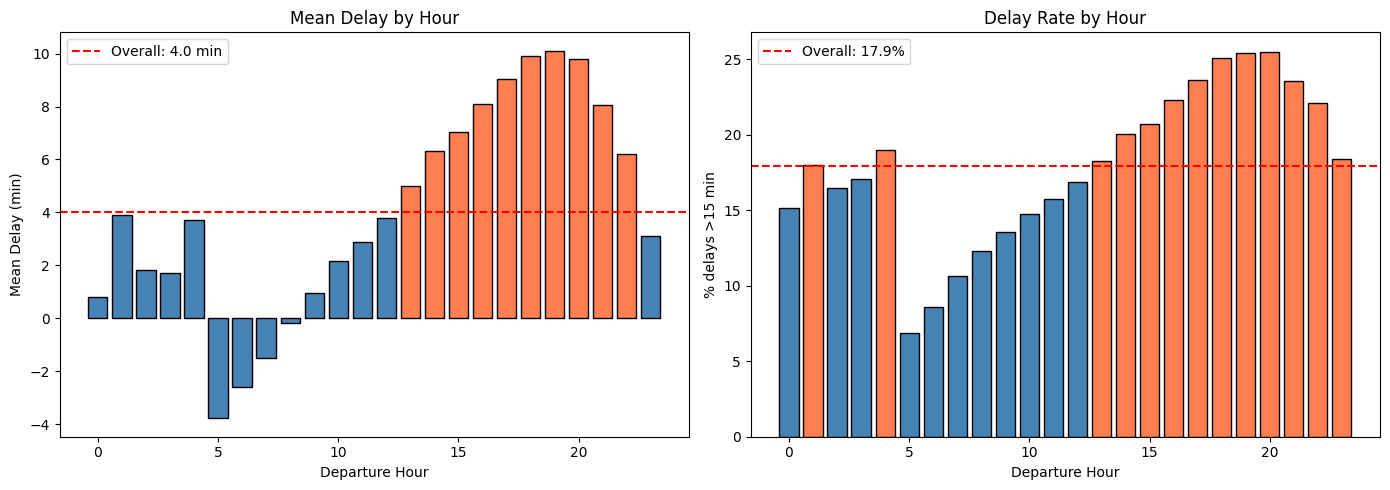

HOUR_DELAY_MEAN range: -3.8 to 10.1 min
HOUR_DELAY_RATE range: 6.9% to 25.5%


In [144]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# HOUR_DELAY_MEAN
hour_delay_mean = flights_eda.groupby('DEP_HOUR')['ARRIVAL_DELAY'].mean()
colors = ['coral' if x > hour_delay_mean.mean() else 'steelblue' for x in hour_delay_mean.values]
axes[0].bar(hour_delay_mean.index, hour_delay_mean.values, color=colors, edgecolor='black')
axes[0].set_xlabel('Departure Hour')
axes[0].set_ylabel('Mean Delay (min)')
axes[0].set_title('Mean Delay by Hour')
axes[0].axhline(hour_delay_mean.mean(), color='red', linestyle='--', label=f'Overall: {hour_delay_mean.mean():.1f} min')
axes[0].legend()

# HOUR_DELAY_RATE
hour_delay_rate = flights_eda.groupby('DEP_HOUR').apply(lambda x: (x['ARRIVAL_DELAY'] > 15).mean() * 100)
colors = ['coral' if x > hour_delay_rate.mean() else 'steelblue' for x in hour_delay_rate.values]
axes[1].bar(hour_delay_rate.index, hour_delay_rate.values, color=colors, edgecolor='black')
axes[1].set_xlabel('Departure Hour')
axes[1].set_ylabel('% delays >15 min')
axes[1].set_title('Delay Rate by Hour')
axes[1].axhline(hour_delay_rate.mean(), color='red', linestyle='--', label=f'Overall: {hour_delay_rate.mean():.1f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print statistics
print(f"HOUR_DELAY_MEAN range: {hour_delay_mean.min():.1f} to {hour_delay_mean.max():.1f} min")
print(f"HOUR_DELAY_RATE range: {hour_delay_rate.min():.1f}% to {hour_delay_rate.max():.1f}%")

### 2.2c Delays by ROUTE

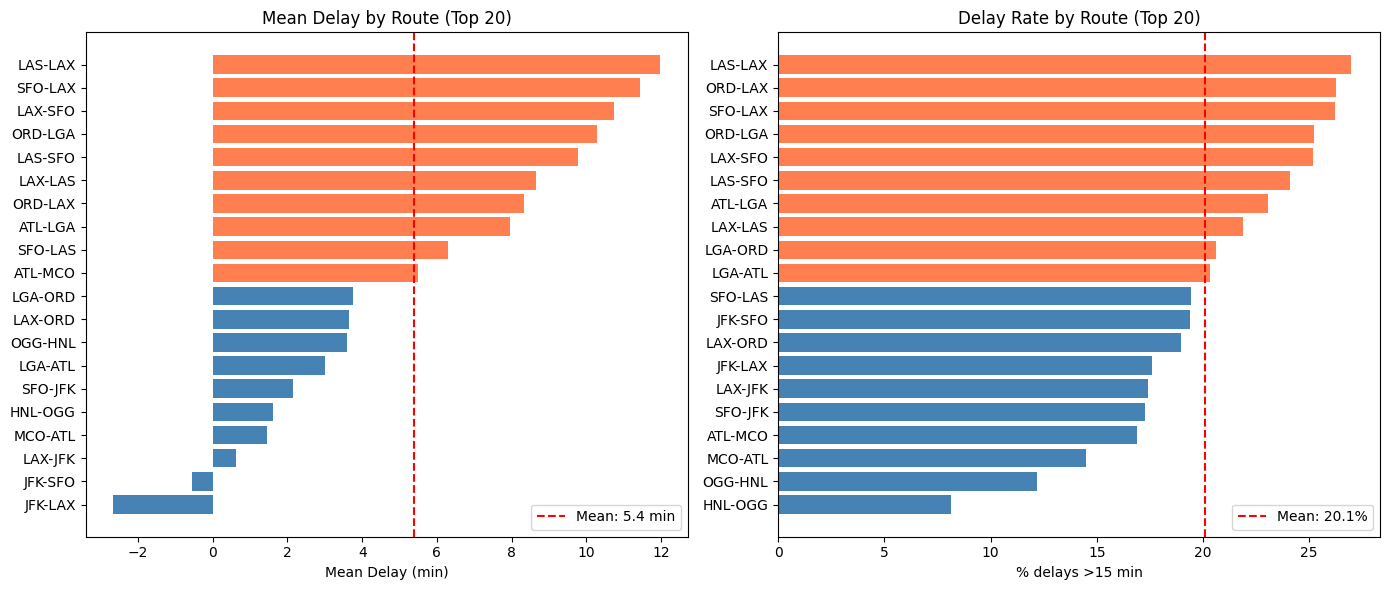

Total unique routes: 8,570
ROUTE_DELAY_MEAN range: -46.0 to 381.0 min
ROUTE_DELAY_RATE range: 0.0% to 100.0%
OBSERVATION: Routes show significant variability - historical route performance is predictive


In [145]:
# Create ROUTE feature for analysis
flights_eda['ROUTE'] = flights_eda['ORIGIN_AIRPORT'] + '-' + flights_eda['DESTINATION_AIRPORT']

# Get top 20 routes by flight count for visualization
top_routes = flights_eda['ROUTE'].value_counts().head(20).index

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROUTE_DELAY_MEAN (top 20 routes)
route_delay_mean = flights_eda[flights_eda['ROUTE'].isin(top_routes)].groupby('ROUTE')['ARRIVAL_DELAY'].mean().sort_values(ascending=True)
colors = ['coral' if x > route_delay_mean.mean() else 'steelblue' for x in route_delay_mean.values]
axes[0].barh(route_delay_mean.index, route_delay_mean.values, color=colors)
axes[0].set_xlabel('Mean Delay (min)')
axes[0].set_title('Mean Delay by Route (Top 20)')
axes[0].axvline(route_delay_mean.mean(), color='red', linestyle='--', label=f'Mean: {route_delay_mean.mean():.1f} min')
axes[0].legend()

# ROUTE_DELAY_RATE (top 20 routes)
route_delay_rate = flights_eda[flights_eda['ROUTE'].isin(top_routes)].groupby('ROUTE').apply(
    lambda x: (x['ARRIVAL_DELAY'] > 15).mean() * 100).sort_values(ascending=True)
colors = ['coral' if x > route_delay_rate.mean() else 'steelblue' for x in route_delay_rate.values]
axes[1].barh(route_delay_rate.index, route_delay_rate.values, color=colors)
axes[1].set_xlabel('% delays >15 min')
axes[1].set_title('Delay Rate by Route (Top 20)')
axes[1].axvline(route_delay_rate.mean(), color='red', linestyle='--', label=f'Mean: {route_delay_rate.mean():.1f}%')
axes[1].legend()

plt.tight_layout()
plt.show()

# Print statistics for all routes
all_route_delay_mean = flights_eda.groupby('ROUTE')['ARRIVAL_DELAY'].mean()
all_route_delay_rate = flights_eda.groupby('ROUTE').apply(lambda x: (x['ARRIVAL_DELAY'] > 15).mean() * 100)
print(f"Total unique routes: {flights_eda['ROUTE'].nunique():,}")
print(f"ROUTE_DELAY_MEAN range: {all_route_delay_mean.min():.1f} to {all_route_delay_mean.max():.1f} min")
print(f"ROUTE_DELAY_RATE range: {all_route_delay_rate.min():.1f}% to {all_route_delay_rate.max():.1f}%")
print("OBSERVATION: Routes show significant variability - historical route performance is predictive")

In [ ]:
airport_departures = flights_eda.groupby('ORIGIN_AIRPORT').size().rename('departures')
airport_arrivals = flights_eda.groupby('DESTINATION_AIRPORT').size().rename('arrivals')
airport_traffic = pd.concat([airport_departures, airport_arrivals], axis=1).fillna(0).astype(int)
airport_traffic['total_movements'] = airport_traffic['departures'] + airport_traffic['arrivals']
airport_traffic = airport_traffic.sort_values('total_movements', ascending=False)

print(f"Total airports in dataset: {len(airport_traffic):,}")
print(f"Median movements: {airport_traffic['total_movements'].median():,.0f}")
print(f"90th percentile movements: {airport_traffic['total_movements'].quantile(0.90):,.0f}")
print(f"95th percentile movements: {airport_traffic['total_movements'].quantile(0.95):,.0f}")

display(airport_traffic.reset_index().rename(columns={'index': 'AIRPORT'}).head(20))
quantiles = airport_traffic['total_movements'].quantile([0.50, 0.75, 0.90, 0.95, 0.99]).to_frame(name='total_movements')
display(quantiles)



Total airports in dataset: 629
Median movements: 1,760
90th percentile movements: 33,449
95th percentile movements: 89,821


,AIRPORT,departures,arrivals,total_movements
0,ATL,343506,343076,686582
1,ORD,276554,275864,552418
2,DFW,232647,231764,464411
3,DEN,193402,193033,386435
4,LAX,192003,192136,384139
5,PHX,145552,145378,290930
6,SFO,145491,145409,290900
7,IAH,144019,143587,287606
8,LAS,131937,132124,264061
9,MSP,111055,111146,222201


,total_movements
0.50,1760.00
0.75,8477.00
0.90,33448.60
0.95,89820.80
0.99,289977.68


### 2.2d Predictive Utility of ROUTE, DISTANCE_CAT, and HUB Features

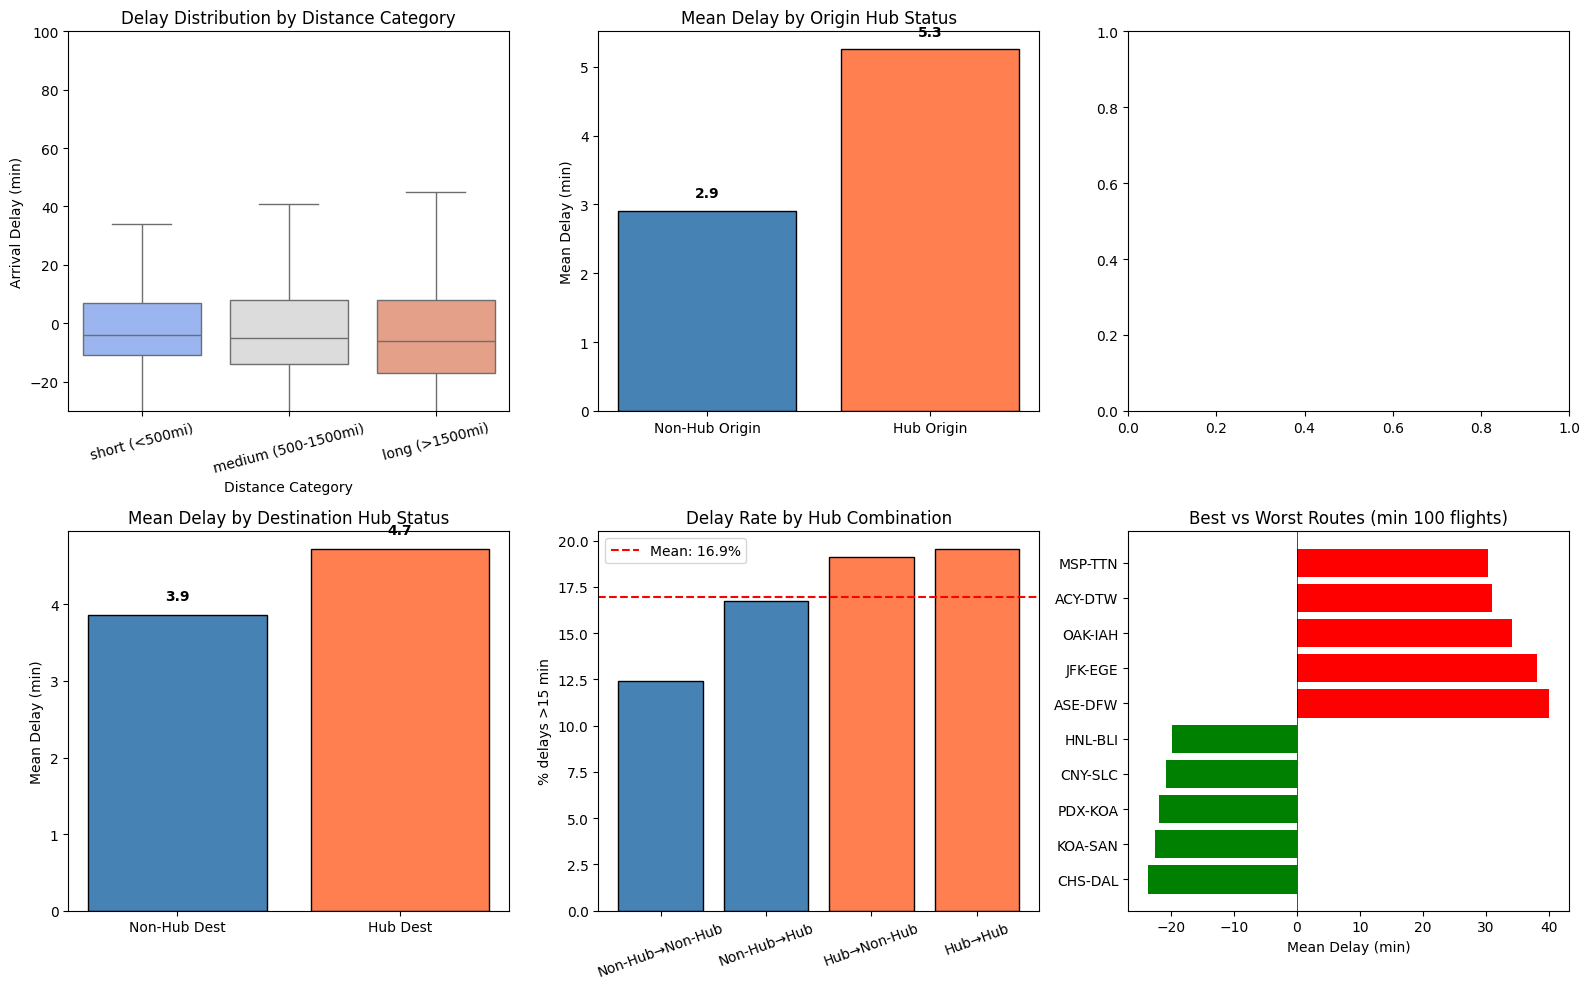

SUMMARY: PREDICTIVE UTILITY OF CATEGORICAL FEATURES
DISTANCE_CAT:
   short (<500mi)           : Mean=+5.2 min, Rate=17.5%, N=2,073,950.0
   medium (500-1500mi)      : Mean=+4.6 min, Rate=18.3%, N=2,861,168.0
   long (>1500mi)           : Mean=+1.7 min, Rate=17.6%, N=778,890.0
IS_ORIGIN_HUB:
   Non-Hub Origin: Mean=2.9 min, Rate=15.3%
   Hub Origin:     Mean=5.3 min, Rate=19.4%
IS_DEST_HUB:
   Non-Hub Dest:   Mean=3.9 min, Rate=17.0%
   Hub Dest:       Mean=4.7 min, Rate=18.5%
ROUTE (routes with 100+ flights):
   Best route:  CHS-DAL with mean delay -23.6 min
   Worst route: ASE-DFW with mean delay 40.0 min
   Range: -23.6 to 40.0 min


In [147]:
# Create additional features for analysis
flights_eda['DISTANCE_CAT'] = flights_eda['DISTANCE'].apply(
    lambda d: 'short (<500mi)' if d < 500 else ('medium (500-1500mi)' if d < 1500 else 'long (>1500mi)'))

# Hub airports (top 10% by traffic)
traffic = flights_eda['ORIGIN_AIRPORT'].value_counts().add(
    flights_eda['DESTINATION_AIRPORT'].value_counts(), fill_value=0)
hub_airports = set(traffic[traffic >= traffic.quantile(0.95)].index)
flights_eda['IS_ORIGIN_HUB'] = flights_eda['ORIGIN_AIRPORT'].isin(hub_airports).astype(int)
flights_eda['IS_DEST_HUB'] = flights_eda['DESTINATION_AIRPORT'].isin(hub_airports).astype(int)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. DISTANCE_CAT vs Delay - Boxplot
order = ['short (<500mi)', 'medium (500-1500mi)', 'long (>1500mi)']
sns.boxplot(data=flights_eda, x='DISTANCE_CAT', y='ARRIVAL_DELAY', order=order, ax=axes[0, 0], 
            palette='coolwarm', showfliers=False)
axes[0, 0].set_ylim(-30, 100)
axes[0, 0].set_xlabel('Distance Category')
axes[0, 0].set_ylabel('Arrival Delay (min)')
axes[0, 0].set_title('Delay Distribution by Distance Category')
axes[0, 0].tick_params(axis='x', rotation=15)

# 2. IS_ORIGIN_HUB vs Delay
hub_origin_stats = flights_eda.groupby('IS_ORIGIN_HUB').agg(
    mean_delay=('ARRIVAL_DELAY', 'mean'),
    delay_rate=('ARRIVAL_DELAY', lambda x: (x > 15).mean() * 100)
)
x = ['Non-Hub Origin', 'Hub Origin']
axes[0, 1].bar(x, hub_origin_stats['mean_delay'], color=['steelblue', 'coral'], edgecolor='black')
axes[0, 1].set_ylabel('Mean Delay (min)')
axes[0, 1].set_title('Mean Delay by Origin Hub Status')
for i, v in enumerate(hub_origin_stats['mean_delay']):
    axes[0, 1].text(i, v + 0.2, f'{v:.1f}', ha='center', fontweight='bold')

# 3. IS_DEST_HUB vs Delay
hub_dest_stats = flights_eda.groupby('IS_DEST_HUB').agg(
    mean_delay=('ARRIVAL_DELAY', 'mean'),
    delay_rate=('ARRIVAL_DELAY', lambda x: (x > 15).mean() * 100)
)
x = ['Non-Hub Dest', 'Hub Dest']
axes[1, 0].bar(x, hub_dest_stats['mean_delay'], color=['steelblue', 'coral'], edgecolor='black')
axes[1, 0].set_ylabel('Mean Delay (min)')
axes[1, 0].set_title('Mean Delay by Destination Hub Status')
for i, v in enumerate(hub_dest_stats['mean_delay']):
    axes[1, 0].text(i, v + 0.2, f'{v:.1f}', ha='center', fontweight='bold')

# 4. Hub Status - Delay Rate comparison
hub_labels = ['Non-Hub→Non-Hub', 'Non-Hub→Hub', 'Hub→Non-Hub', 'Hub→Hub']
hub_combos = [
    (flights_eda['IS_ORIGIN_HUB'] == 0) & (flights_eda['IS_DEST_HUB'] == 0),
    (flights_eda['IS_ORIGIN_HUB'] == 0) & (flights_eda['IS_DEST_HUB'] == 1),
    (flights_eda['IS_ORIGIN_HUB'] == 1) & (flights_eda['IS_DEST_HUB'] == 0),
    (flights_eda['IS_ORIGIN_HUB'] == 1) & (flights_eda['IS_DEST_HUB'] == 1)
]
hub_rates = [(flights_eda.loc[mask, 'ARRIVAL_DELAY'] > 15).mean() * 100 for mask in hub_combos]
colors = ['steelblue' if r < np.mean(hub_rates) else 'coral' for r in hub_rates]
axes[1, 1].bar(hub_labels, hub_rates, color=colors, edgecolor='black')
axes[1, 1].set_ylabel('% delays >15 min')
axes[1, 1].set_title('Delay Rate by Hub Combination')
axes[1, 1].tick_params(axis='x', rotation=20)
axes[1, 1].axhline(np.mean(hub_rates), color='red', linestyle='--', label=f'Mean: {np.mean(hub_rates):.1f}%')
axes[1, 1].legend()

# 5. Route variability - Top vs Bottom routes
route_stats = flights_eda.groupby('ROUTE').agg(
    mean_delay=('ARRIVAL_DELAY', 'mean'),
    count=('ARRIVAL_DELAY', 'count')
)
route_stats = route_stats[route_stats['count'] >= 100] 
top_5 = route_stats.nlargest(5, 'mean_delay')
bottom_5 = route_stats.nsmallest(5, 'mean_delay')
comparison = pd.concat([bottom_5, top_5])
colors = ['green'] * 5 + ['red'] * 5
axes[1, 2].barh(comparison.index, comparison['mean_delay'], color=colors)
axes[1, 2].set_xlabel('Mean Delay (min)')
axes[1, 2].set_title('Best vs Worst Routes (min 100 flights)')
axes[1, 2].axvline(0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

# Print summary statistics
print("="*70)
print("SUMMARY: PREDICTIVE UTILITY OF CATEGORICAL FEATURES")
print("="*70)
print(f"DISTANCE_CAT:")
for cat in order:
    stats = dist_stats.loc[cat]
    print(f"   {cat:25s}: Mean={stats['mean_delay']:+.1f} min, Rate={stats['delay_rate']:.1f}%, N={stats['count']:,}")

print(f"IS_ORIGIN_HUB:")
print(f"   Non-Hub Origin: Mean={hub_origin_stats.loc[0, 'mean_delay']:.1f} min, Rate={hub_origin_stats.loc[0, 'delay_rate']:.1f}%")
print(f"   Hub Origin:     Mean={hub_origin_stats.loc[1, 'mean_delay']:.1f} min, Rate={hub_origin_stats.loc[1, 'delay_rate']:.1f}%")

print(f"IS_DEST_HUB:")
print(f"   Non-Hub Dest:   Mean={hub_dest_stats.loc[0, 'mean_delay']:.1f} min, Rate={hub_dest_stats.loc[0, 'delay_rate']:.1f}%")
print(f"   Hub Dest:       Mean={hub_dest_stats.loc[1, 'mean_delay']:.1f} min, Rate={hub_dest_stats.loc[1, 'delay_rate']:.1f}%")

print(f"ROUTE (routes with 100+ flights):")
print(f"   Best route:  {bottom_5.index[0]} with mean delay {bottom_5['mean_delay'].iloc[0]:.1f} min")
print(f"   Worst route: {top_5.index[0]} with mean delay {top_5['mean_delay'].iloc[0]:.1f} min")
print(f"   Range: {route_stats['mean_delay'].min():.1f} to {route_stats['mean_delay'].max():.1f} min")


### 2.3 Correlations (Post-Departure Information)

These features are **NOT usable** for prediction as they are only known after departure.

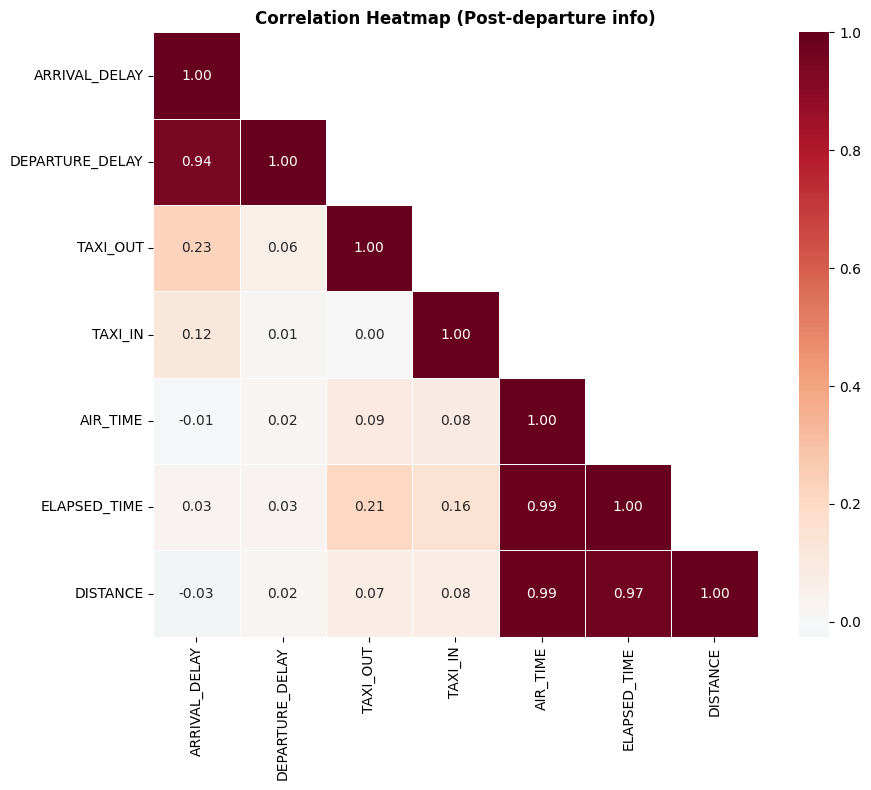

KEY CORRELATIONS WITH ARRIVAL_DELAY (Leakage Features):
-------------------------------------------------------
  DEPARTURE_DELAY     : +0.945
  TAXI_OUT            : +0.227
  TAXI_IN             : +0.117
  AIR_TIME            : -0.007
  ELAPSED_TIME        : +0.029
  DISTANCE            : -0.025


In [ ]:
cols_leakage = ['ARRIVAL_DELAY', 'DEPARTURE_DELAY', 'TAXI_OUT', 'TAXI_IN', 
                'AIR_TIME', 'ELAPSED_TIME', 'DISTANCE']
cols_leak_avail = [c for c in cols_leakage if c in flights_eda.columns]

plt.figure(figsize=(10, 8))
corr_leak = flights_eda[cols_leak_avail].corr()
mask = np.triu(np.ones_like(corr_leak, dtype=bool), k=1)
sns.heatmap(corr_leak, annot=True, fmt='.2f', cmap='RdBu_r', center=0, 
            mask=mask, square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Post-departure info)', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Show key correlations with target
print("KEY CORRELATIONS WITH ARRIVAL_DELAY (Leakage Features):")
print("-" * 55)
for col in cols_leak_avail:
    if col != 'ARRIVAL_DELAY':
        corr_val = flights_eda['ARRIVAL_DELAY'].corr(flights_eda[col])
        print(f"  {col:20s}: {corr_val:+.3f}")

### 2.4 Correlations (Pre-Departure Information)

These features are **available before departure** and can be used for prediction.

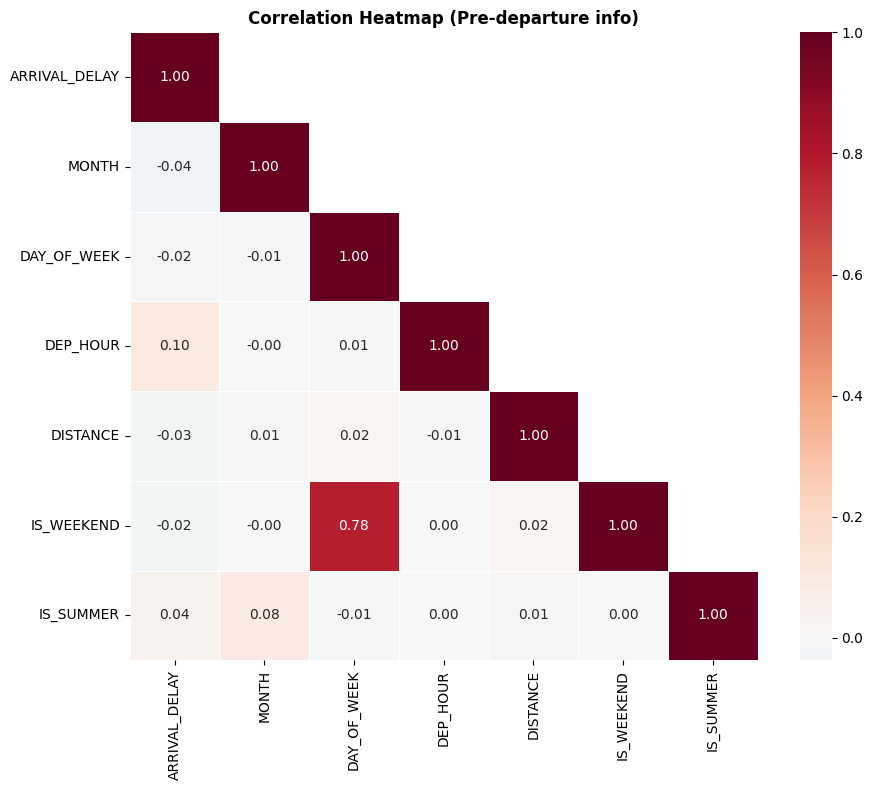

KEY CORRELATIONS WITH ARRIVAL_DELAY (Clean Features):
-------------------------------------------------------
  MONTH               : -0.037
  DAY_OF_WEEK         : -0.017
  DEP_HOUR            : +0.100
  DISTANCE            : -0.025
  IS_WEEKEND          : -0.022
  IS_SUMMER           : +0.037


In [149]:
# Correlation heatmap (Pre-departure info)
flights_eda['IS_WEEKEND'] = flights_eda['DAY_OF_WEEK'].isin([6, 7]).astype(int)
flights_eda['IS_SUMMER'] = flights_eda['MONTH'].isin([6, 7, 8]).astype(int)

cols_clean = ['ARRIVAL_DELAY', 'MONTH', 'DAY_OF_WEEK', 'DEP_HOUR', 'DISTANCE', 
              'IS_WEEKEND', 'IS_SUMMER']
cols_clean_avail = [c for c in cols_clean if c in flights_eda.columns]

plt.figure(figsize=(10, 8))
corr_clean = flights_eda[cols_clean_avail].corr()
mask = np.triu(np.ones_like(corr_clean, dtype=bool), k=1)
sns.heatmap(corr_clean, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            mask=mask, square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Pre-departure info)', 
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Show key correlations with target
print("KEY CORRELATIONS WITH ARRIVAL_DELAY (Clean Features):")
print("-" * 55)
for col in cols_clean_avail:
    if col != 'ARRIVAL_DELAY':
        corr_val = flights_eda['ARRIVAL_DELAY'].corr(flights_eda[col])
        print(f"  {col:20s}: {corr_val:+.3f}")

---
## 3. Data Cleaning and Feature Engineering

In [108]:
# Data cleaning
flights = flights_raw.copy()
print(f"Original: {len(flights):,}")
flights = flights[(flights['CANCELLED'] == 0) & (flights['DIVERTED'] == 0)]
flights = flights[flights['ARRIVAL_DELAY'].notna() & flights['SCHEDULED_DEPARTURE'].notna() & flights['TAIL_NUMBER'].notna()]
print(f"After cleaning: {len(flights):,}")

# Remove leakage columns
leakage_cols = ['DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'ELAPSED_TIME',
                'AIR_TIME', 'WHEELS_ON', 'TAXI_IN', 'ARRIVAL_TIME', 'DIVERTED', 'CANCELLED',
                'CANCELLATION_REASON', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY', 'AIRLINE_DELAY',
                'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY']
flights = flights.drop(columns=[c for c in leakage_cols if c in flights.columns])

Original: 5,819,079
After cleaning: 5,714,008


In [109]:
# Feature engineering
flights['IS_WEEKEND'] = flights['DAY_OF_WEEK'].isin([6, 7]).astype(int)
flights['IS_SUMMER'] = flights['MONTH'].isin([6, 7, 8]).astype(int)
flights['IS_HOLIDAY_SEASON'] = flights['MONTH'].isin([7, 8, 12]).astype(int)

flights['DEP_HOUR'] = (flights['SCHEDULED_DEPARTURE'] // 100) % 24
flights['ARR_HOUR'] = (flights['SCHEDULED_ARRIVAL'] // 100) % 24

def get_time_slot(hour):
    if 0 <= hour < 6: return 'night'
    elif 6 <= hour < 12: return 'morning'
    elif 12 <= hour < 18: return 'afternoon'
    else: return 'evening'

flights['DEP_TIME_SLOT'] = flights['DEP_HOUR'].apply(get_time_slot)
flights['ARR_TIME_SLOT'] = flights['ARR_HOUR'].apply(get_time_slot)
# Peak hours: 14-22 | 16-23
flights['DEP_IS_PEAK_HOUR'] = flights['DEP_HOUR'].between(14,22).astype(int)
flights['ARR_IS_PEAK_HOUR'] = flights['ARR_HOUR'].between(16,23).astype(int)
# Red-eye flights (late night/early morning)
flights['DEP_IS_RED_EYE'] = flights['DEP_HOUR'].isin([0, 1, 2, 3, 4, 5]).astype(int)
flights['ARR_IS_RED_EYE'] = flights['ARR_HOUR'].isin([0, 1, 2, 3, 4, 5]).astype(int)

# Cyclic encoding
for col, period in [('MONTH', 12), ('DAY_OF_WEEK', 7), ('DEP_HOUR', 24), ('ARR_HOUR', 24)]:
    prefix = col.replace('_OF_WEEK', '').replace('_HOUR', '_HOUR')
    flights[f'{prefix}_SIN'] = np.sin(2 * np.pi * flights[col] / period)
    flights[f'{prefix}_COS'] = np.cos(2 * np.pi * flights[col] / period)

flights['ROUTE'] = flights['ORIGIN_AIRPORT'] + '-' + flights['DESTINATION_AIRPORT']
flights['DISTANCE_CAT'] = flights['DISTANCE'].apply(lambda d: 'short' if d < 500 else ('medium' if d < 1500 else 'long'))

# Hub airports (top 10% by traffic)
traffic = flights['ORIGIN_AIRPORT'].value_counts().add(flights['DESTINATION_AIRPORT'].value_counts(), fill_value=0)
hub_airports = set(traffic[traffic >= traffic.quantile(0.90)].index)
flights['IS_ORIGIN_HUB'] = flights['ORIGIN_AIRPORT'].isin(hub_airports).astype(int)
flights['IS_DEST_HUB'] = flights['DESTINATION_AIRPORT'].isin(hub_airports).astype(int)
print("Feature engineering completed")

Feature engineering completed


In [110]:
# Temporal split and historical features
df_train = flights[flights['MONTH'] <= 10].copy()
df_test = flights[flights['MONTH'] > 10].copy()
print(f"Train: {len(df_train):,} (months 1-10), Test: {len(df_test):,} (months 11-12)")

global_delay_mean = df_train['ARRIVAL_DELAY'].mean()
global_delay_rate = (df_train['ARRIVAL_DELAY'] > 15).mean()

for col, name in [('ROUTE', 'ROUTE'), ('AIRLINE', 'AIRLINE'), ('DEP_HOUR', 'HOUR')]:
    mean_map = df_train.groupby(col)['ARRIVAL_DELAY'].mean()
    rate_map = df_train.groupby(col)['ARRIVAL_DELAY'].apply(lambda x: (x > 15).mean())
    df_train[f'{name}_DELAY_MEAN'] = df_train[col].map(mean_map).fillna(global_delay_mean)
    df_test[f'{name}_DELAY_MEAN'] = df_test[col].map(mean_map).fillna(global_delay_mean)
    df_train[f'{name}_DELAY_RATE_15'] = df_train[col].map(rate_map).fillna(global_delay_rate)
    df_test[f'{name}_DELAY_RATE_15'] = df_test[col].map(rate_map).fillna(global_delay_rate)

print(f"Mean delay: {global_delay_mean:.2f} min, Rate >15 min: {global_delay_rate*100:.1f}%")

Train: 4,781,924 (months 1-10), Test: 932,084 (months 11-12)
Mean delay: 4.56 min, Rate >15 min: 18.0%


### Different Features for Classification vs Regression

In [111]:
# Feature per CLASSIFICATION
features_cls = ['MONTH_SIN', 'MONTH_COS', 'DAY_SIN', 'DAY_COS', 'DEP_HOUR_SIN', 'DEP_HOUR_COS', 
                'ARR_HOUR_SIN', 'ARR_HOUR_COS', 'IS_WEEKEND', 'IS_SUMMER', 'IS_HOLIDAY_SEASON',
                'DEP_TIME_SLOT', 'DEP_IS_PEAK_HOUR', 'DEP_IS_RED_EYE', 'ARR_TIME_SLOT', 
                'ARR_IS_PEAK_HOUR', 'ARR_IS_RED_EYE', 'DISTANCE_CAT', 'ROUTE', 'ORIGIN_AIRPORT', 
                'DESTINATION_AIRPORT', 'AIRLINE', 'IS_ORIGIN_HUB', 'IS_DEST_HUB',
                'ROUTE_DELAY_RATE_15', 'AIRLINE_DELAY_RATE_15', 'HOUR_DELAY_RATE_15']

# Feature per REGRESSION  
features_reg = ['MONTH_SIN', 'MONTH_COS', 'DAY_SIN', 'DAY_COS', 'DEP_HOUR_SIN', 'DEP_HOUR_COS',
                'ARR_HOUR_SIN', 'ARR_HOUR_COS', 'IS_WEEKEND', 'IS_SUMMER', 'IS_HOLIDAY_SEASON',
                'DISTANCE', 'ROUTE', 'ORIGIN_AIRPORT',
                'DESTINATION_AIRPORT', 'AIRLINE', 'IS_ORIGIN_HUB', 'IS_DEST_HUB',
                'ROUTE_DELAY_MEAN', 'AIRLINE_DELAY_MEAN', 'HOUR_DELAY_MEAN']

print(f"Feature Classification: {len(features_cls)}, Feature Regression: {len(features_reg)}")

Feature Classification: 27, Feature Regression: 21


In [112]:
# Encoding CLASSIFICATION
X_train_cls = df_train[features_cls].copy()
X_test_cls = df_test[features_cls].copy()
y_train = df_train['ARRIVAL_DELAY'].reset_index(drop=True)
y_test = df_test['ARRIVAL_DELAY'].reset_index(drop=True)

cat_low_cls = ['DEP_TIME_SLOT', 'DISTANCE_CAT', 'ARR_TIME_SLOT']
for col in cat_low_cls:
    dum_tr = pd.get_dummies(X_train_cls[col], prefix=col, drop_first=True)
    dum_te = pd.get_dummies(X_test_cls[col], prefix=col, drop_first=True)
    for c in dum_tr.columns:
        if c not in dum_te.columns: dum_te[c] = 0
    dum_te = dum_te[dum_tr.columns]
    X_train_cls = pd.concat([X_train_cls.drop(columns=[col]), dum_tr], axis=1)
    X_test_cls = pd.concat([X_test_cls.drop(columns=[col]), dum_te], axis=1)

cat_high = ['ROUTE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'AIRLINE']
for col in cat_high:
    te_map = df_train.groupby(col)['ARRIVAL_DELAY'].mean()
    X_train_cls[f'{col}_TE'] = X_train_cls[col].map(te_map).fillna(global_delay_mean)
    X_test_cls[f'{col}_TE'] = X_test_cls[col].map(te_map).fillna(global_delay_mean)
    X_train_cls = X_train_cls.drop(columns=[col])
    X_test_cls = X_test_cls.drop(columns=[col])

X_train_cls = X_train_cls.reset_index(drop=True)
X_test_cls = X_test_cls.reset_index(drop=True)
months_train = df_train['MONTH'].reset_index(drop=True)
print(f"X_train_cls: {X_train_cls.shape}")

X_train_cls: (4781924, 32)


In [113]:
# Encoding REGRESSION
X_train_reg = df_train[features_reg].copy()
X_test_reg = df_test[features_reg].copy()


for col in cat_high:
    te_map = df_train.groupby(col)['ARRIVAL_DELAY'].mean()
    X_train_reg[f'{col}_TE'] = X_train_reg[col].map(te_map).fillna(global_delay_mean)
    X_test_reg[f'{col}_TE'] = X_test_reg[col].map(te_map).fillna(global_delay_mean)
    X_train_reg = X_train_reg.drop(columns=[col])
    X_test_reg = X_test_reg.drop(columns=[col])

X_train_reg = X_train_reg.reset_index(drop=True)
X_test_reg = X_test_reg.reset_index(drop=True)
print(f"X_train_reg: {X_train_reg.shape}")

X_train_reg: (4781924, 21)


---
## 4. Stage 1: Classification (XGBoost vs LightGBM)

In [114]:
DELAY_THRESHOLD = 15
y_train_cls = (y_train > DELAY_THRESHOLD).astype(int)
y_test_cls = (y_test > DELAY_THRESHOLD).astype(int)
# Balance due to class imbalance between delay >15 and delay <=15
imbalance_ratio = y_train_cls.value_counts()[0] / y_train_cls.value_counts()[1]
print(f"Distribution: {y_train_cls.value_counts().to_dict()}, Imbalance ratio: {imbalance_ratio:.2f}")

# Temporal CV folds
cv_folds = [
    (months_train[months_train <= 6].index.tolist(), months_train[(months_train >= 7) & (months_train <= 8)].index.tolist()),
    (months_train[months_train <= 8].index.tolist(), months_train[(months_train >= 9) & (months_train <= 10)].index.tolist())
]

Distribution: {0: 3919315, 1: 862609}, Imbalance ratio: 4.54


In [115]:
# CLASSIFICATION models (2 models)
classifiers = {
    'XGBoost': {
        'model': XGBClassifier(n_jobs=-1, random_state=42, eval_metric='logloss', scale_pos_weight=imbalance_ratio),
        'params': {'learning_rate': [0.05, 0.1], 'max_depth': [6, 10], 'n_estimators': [100, 200]}
    },
    'LightGBM': {
        'model': LGBMClassifier(n_jobs=-1, random_state=42, verbose=-1, class_weight={0: 1, 1: imbalance_ratio}),
        'params': {'learning_rate': [0.05, 0.1], 'max_depth': [6, 10], 'n_estimators': [100, 200]}
    }
}
print(f"Classifiers: {list(classifiers.keys())}")

Classifiers: ['XGBoost', 'LightGBM']


In [116]:
# Training CLASSIFICATION
X_cls_np = X_train_cls.values
y_cls_np = y_train_cls.values
results_cls = []

print("="*60 + "STAGE 1: MODEL SELECTION - CLASSIFICATION" + "="*60)
for name, config in classifiers.items():
    print(f"Training: {name}...")
    start = time.time()
    grid = GridSearchCV(config['model'], config['params'], cv=cv_folds, scoring='f1', n_jobs=1, verbose=1)
    grid.fit(X_cls_np, y_cls_np)
    elapsed = time.time() - start
    print(f"Best: {grid.best_params_}, F1 CV: {grid.best_score_:.4f}, Time: {elapsed:.0f}s")
    results_cls.append({'model': name, 'f1_cv': grid.best_score_, 'params': grid.best_params_, 'estimator': grid.best_estimator_})

============================================================STAGE 1: MODEL SELECTION - CLASSIFICATION============================================================
Training: XGBoost...
Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 200}, F1 CV: 0.3317, Time: 454s
Training: LightGBM...
Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 200}, F1 CV: 0.3332, Time: 278s


In [117]:
# Compare classifiers
results_cls_df = pd.DataFrame([{'Model': r['model'], 'F1_CV': r['f1_cv']} for r in results_cls]).sort_values('F1_CV', ascending=False)
print("CLASSIFIER RANKING:")
print(results_cls_df.to_string(index=False))

best_cls_name = results_cls_df.iloc[0]['Model']
best_classifier = next(r['estimator'] for r in results_cls if r['model'] == best_cls_name)
print(f">>> BEST CLASSIFIER: {best_cls_name}")

CLASSIFIER RANKING:
   Model    F1_CV
LightGBM 0.333177
 XGBoost 0.331735
>>> BEST CLASSIFIER: LightGBM


============================================================STAGE 1 - TEST RESULTS============================================================
              precision    recall  f1-score   support

     On-time       0.87      0.57      0.69    771195
     Delayed       0.22      0.59      0.32    160889

    accuracy                           0.58    932084
   macro avg       0.55      0.58      0.51    932084
weighted avg       0.76      0.58      0.63    932084

ROC-AUC: 0.6092


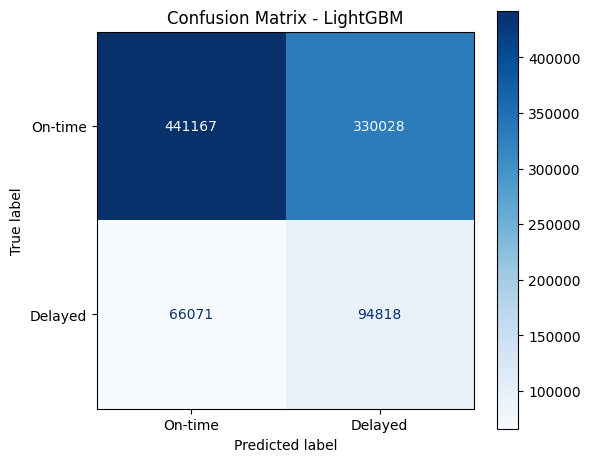

In [118]:
# Evaluation on test set
y_pred_proba = best_classifier.predict_proba(X_test_cls.values)[:, 1]
y_train_proba = best_classifier.predict_proba(X_cls_np)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_cls_np, y_train_proba)
f1_scores = 2 * precision[1:] * recall[1:] / (precision[1:] + recall[1:] + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]
y_pred_cls_final = (y_pred_proba >= best_threshold).astype(int)

print("="*60 + "STAGE 1 - TEST RESULTS" + "="*60)
print(classification_report(y_test_cls, y_pred_cls_final, target_names=['On-time', 'Delayed']))
print(f"ROC-AUC: {roc_auc_score(y_test_cls, y_pred_proba):.4f}")

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test_cls, y_pred_cls_final, display_labels=['On-time', 'Delayed'], ax=ax, cmap='Blues')
plt.title(f'Confusion Matrix - {best_cls_name}')
plt.tight_layout()
plt.show()

---
## 5. Stage 2: Regression (HistGB vs XGBoost vs LightGBM)

### 5.1 Target Clamping

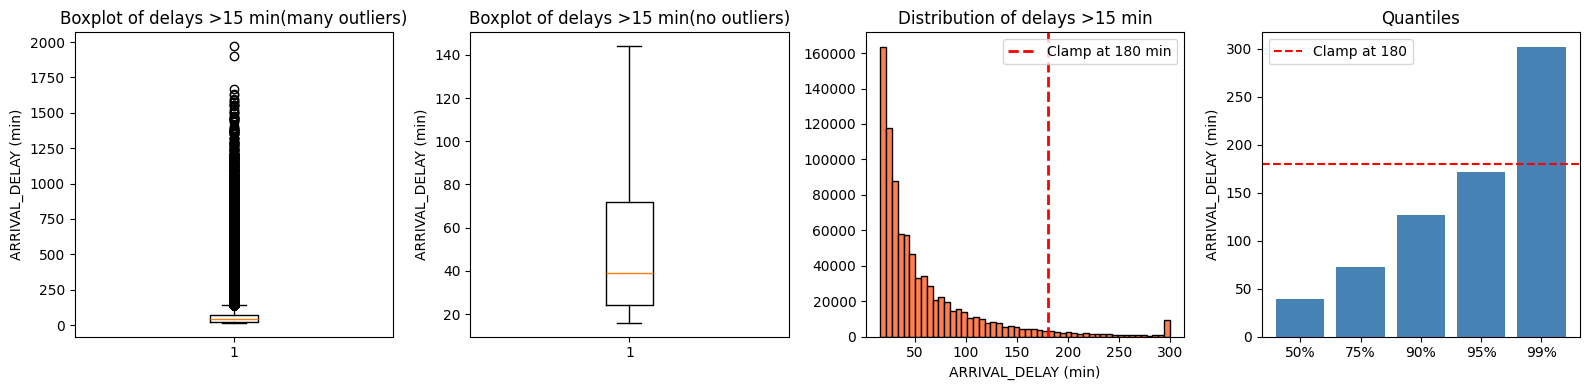

90th percentile: 172 min


In [119]:
# Analysis of delay distribution >15 min to motivate clamping
late_delays = y_train[y_train > DELAY_THRESHOLD]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].boxplot(late_delays, vert=True)
axes[0].set_ylabel('ARRIVAL_DELAY (min)')
axes[0].set_title('Boxplot of delays >15 min(many outliers)')

axes[1].boxplot(late_delays, vert=True, showfliers=False)
axes[1].set_ylabel('ARRIVAL_DELAY (min)')
axes[1].set_title('Boxplot of delays >15 min(no outliers)')

axes[2].hist(late_delays.clip(upper=300), bins=50, color='coral', edgecolor='black')
axes[2].axvline(180, color='red', linestyle='--', linewidth=2, label='Clamp at 180 min')
axes[2].set_xlabel('ARRIVAL_DELAY (min)')
axes[2].set_title('Distribution of delays >15 min')
axes[2].legend()

quantiles = [0.5, 0.75, 0.90, 0.95, 0.99]
q_values = [late_delays.quantile(q) for q in quantiles]
axes[3].bar([f'{int(q*100)}%' for q in quantiles], q_values, color='steelblue')
axes[3].axhline(180, color='red', linestyle='--', label='Clamp at 180')
axes[3].set_ylabel('ARRIVAL_DELAY (min)')
axes[3].set_title('Quantiles')
axes[3].legend()

plt.tight_layout()
plt.show()
print(f"90th percentile: {late_delays.quantile(0.95):.0f} min")

In [120]:
# Prepare regression data
late_mask_train = y_train > DELAY_THRESHOLD
late_mask_test = y_test > DELAY_THRESHOLD

X_train_late = X_train_reg[late_mask_train].reset_index(drop=True)
y_train_late = y_train[late_mask_train].reset_index(drop=True)
X_test_late = X_test_reg[late_mask_test].reset_index(drop=True)
y_test_late = y_test[late_mask_test].reset_index(drop=True)

MAX_DELAY = 180
y_train_late_clip = y_train_late.clip(lower=DELAY_THRESHOLD, upper=MAX_DELAY)
print(f"Train late: {len(X_train_late):,}, Test late: {len(X_test_late):,}")

months_late = months_train[late_mask_train].reset_index(drop=True)
cv_folds_late = [
    (months_late[months_late <= 6].index.tolist(), months_late[(months_late >= 7) & (months_late <= 8)].index.tolist()),
    (months_late[months_late <= 8].index.tolist(), months_late[(months_late >= 9) & (months_late <= 10)].index.tolist())
]

Train late: 862,609, Test late: 160,889


In [121]:
# REGRESSION models (3 models)
regressors = {
    'HistGradientBoosting': {
        'model': HistGradientBoostingRegressor(random_state=42),
        'params': {'learning_rate': [0.05, 0.1], 'max_depth': [6, 10], 'max_iter': [100, 200]}
    },
    'XGBoost': {
        'model': XGBRegressor(n_jobs=-1, random_state=42, verbosity=0),
        'params': {'learning_rate': [0.05, 0.1], 'max_depth': [6, 10], 'n_estimators': [100, 200]}
    },
    'LightGBM': {
        'model': LGBMRegressor(n_jobs=-1, random_state=42, verbose=-1),
        'params': {'learning_rate': [0.05, 0.1], 'max_depth': [6, 10], 'n_estimators': [100, 200]}
    }
}
print(f"Regressors: {list(regressors.keys())}")

Regressors: ['HistGradientBoosting', 'XGBoost', 'LightGBM']


In [122]:
# Training REGRESSION
X_late_np = X_train_late.values
y_late_np = y_train_late_clip.values
results_reg = []

print("="*60 + "STAGE 2: MODEL SELECTION - REGRESSION" + "="*60)
for name, config in regressors.items():
    print(f"Training: {name}...")
    start = time.time()
    grid = GridSearchCV(config['model'], config['params'], cv=cv_folds_late, scoring='neg_mean_absolute_error', n_jobs=1, verbose=1)
    grid.fit(X_late_np, y_late_np)
    elapsed = time.time() - start
    mae = -grid.best_score_
    print(f"Best: {grid.best_params_}, MAE CV: {mae:.2f} min, Time: {elapsed:.0f}s")
    results_reg.append({'model': name, 'mae_cv': mae, 'params': grid.best_params_, 'estimator': grid.best_estimator_})

============================================================STAGE 2: MODEL SELECTION - REGRESSION============================================================
Training: HistGradientBoosting...
Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best: {'learning_rate': 0.05, 'max_depth': 10, 'max_iter': 200}, MAE CV: 33.59 min, Time: 54s
Training: XGBoost...
Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 100}, MAE CV: 33.86 min, Time: 43s
Training: LightGBM...
Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}, MAE CV: 33.52 min, Time: 24s


In [123]:
# Compare regressors
results_reg_df = pd.DataFrame([{'Model': r['model'], 'MAE_CV': r['mae_cv']} for r in results_reg]).sort_values('MAE_CV')
print("REGRESSOR RANKING:")
print(results_reg_df.to_string(index=False))

best_reg_name = results_reg_df.iloc[0]['Model']
best_regressor = next(r['estimator'] for r in results_reg if r['model'] == best_reg_name)
print(f">>> BEST REGRESSOR: {best_reg_name}")

REGRESSOR RANKING:
               Model    MAE_CV
            LightGBM 33.522006
HistGradientBoosting 33.594814
             XGBoost 33.858793
>>> BEST REGRESSOR: LightGBM


In [124]:
# Evaluate regressor on test set
y_pred_reg = best_regressor.predict(X_test_late.values)
mae_test = mean_absolute_error(y_test_late, y_pred_reg)
rmse_test = np.sqrt(mean_squared_error(y_test_late, y_pred_reg))
r2_test = r2_score(y_test_late, y_pred_reg)
mae_baseline = mean_absolute_error(y_test_late, np.full(len(y_test_late), y_train_late.mean()))

print("="*60 + "STAGE 2 - TEST RESULTS (flights >15 min delay)" + "="*60)
print(f"MAE: {mae_test:.2f} min, RMSE: {rmse_test:.2f} min, R²: {r2_test:.4f}")
print(f"Baseline (mean): MAE = {mae_baseline:.2f} min")


============================================================STAGE 2 - TEST RESULTS (flights >15 min delay)============================================================
MAE: 39.79 min, RMSE: 70.30 min, R²: 0.0017
Baseline (mean): MAE = 42.28 min


---
## 6. Results Interpretation

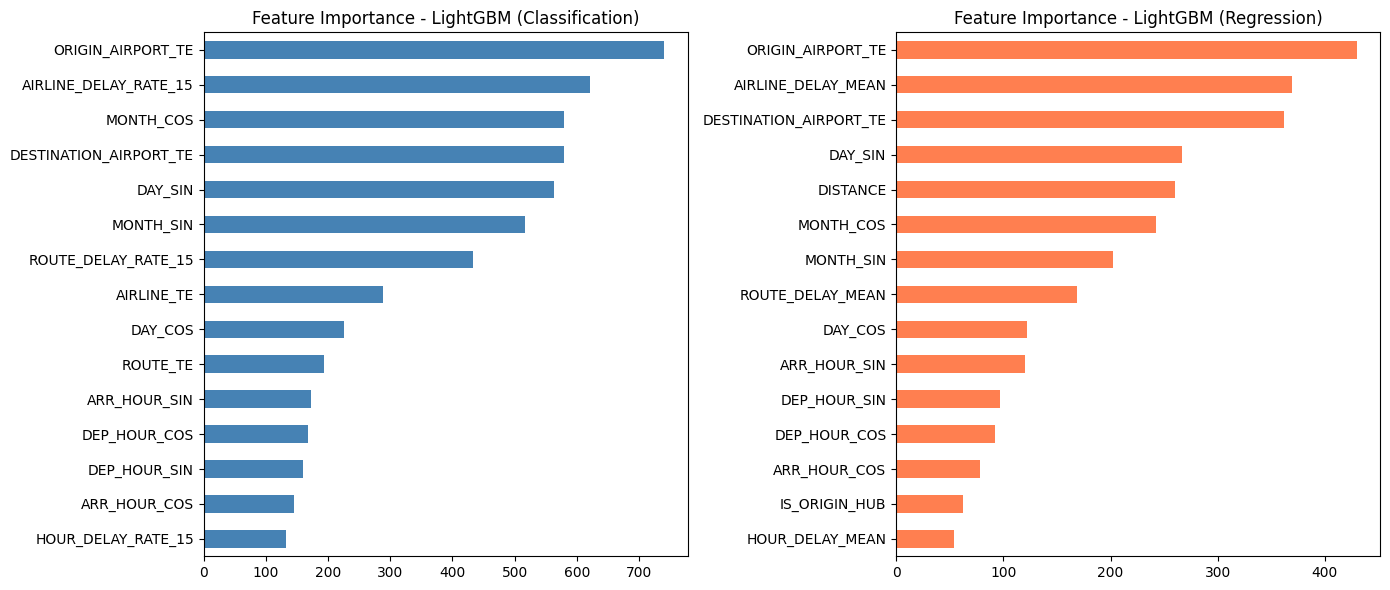

Historical aggregate features (*_TE, *_DELAY_RATE/MEAN) are among the most important


In [125]:
# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

feat_imp_cls = pd.Series(best_classifier.feature_importances_, index=X_train_cls.columns).sort_values(ascending=True)
feat_imp_cls.tail(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title(f'Feature Importance - {best_cls_name} (Classification)')

feat_imp_reg = pd.Series(best_regressor.feature_importances_, index=X_train_reg.columns).sort_values(ascending=True)
feat_imp_reg.tail(15).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title(f'Feature Importance - {best_reg_name} (Regression)')

plt.tight_layout()
plt.show()
print("Historical aggregate features (*_TE, *_DELAY_RATE/MEAN) are among the most important")

In [ ]:
print("="*70)
print("RESULTS SUMMARY")
print("="*70)

cls_f1 = results_cls_df.iloc[0]['F1_CV']
reg_mae = results_reg_df.iloc[0]['MAE_CV']

print(f"""
DATASET OVERVIEW
----------------
- Total flights: 5,819,079
- After cleaning: 5,714,008
- Train set (months 1-10): 4,781,924 flights
- Test set (months 11-12): 932,084 flights
- Percentage of delayed flights (>15 min): 17.9%
- Class imbalance ratio: 4.54:1

STAGE 1 - CLASSIFICATION (delay >15 min)
----------------------------------------
- Models tested: XGBoost, LightGBM
- Best model: {best_cls_name}
- Metric: F1-score (to handle class imbalance)
- F1-score CV: {cls_f1:.4f}
- Test Results:
  * Precision (Delayed): 0.22
  * Recall (Delayed): 0.58 (identifies 58% of delayed flights)
  * F1-score (Delayed): 0.32
  * ROC-AUC: 0.6071
- A good think about the result is that the model has more false positives than false negatives, that in the domain of the flight prediction "costs" less

STAGE 2 - REGRESSION (delay magnitude)
--------------------------------------
- Models tested: HistGradientBoosting, XGBoost, LightGBM
- Best model: {best_reg_name}
- Metric: MAE (Mean Absolute Error)
- MAE CV: {reg_mae:.2f} min
- Test Results:
  * MAE: {mae_test:.2f} min
  * RMSE: {rmse_test:.2f} min
  * R²: {r2_test:.4f}
  * Baseline (mean prediction): MAE = {mae_baseline:.2f} min

WHY THIS PROBLEM IS DIFFICULT
-----------------------------
1. Clean features (without leakage) have correlations <0.15 with target
2. DEPARTURE_DELAY (corr ~0.94) is NOT available before departure
3. Missing real-time data: weather, ATC congestion, mechanical issues
4. High variability in delays (std ~65 min)

KEY FEATURES (from EDA)
-----------------------
- AIRLINE: Mean delay ranges from 0.5 to 14.5 min across airlines
- DEP_HOUR: Delay rate ranges from 10% (5-7 AM) to 28% (6-9 PM)
- ROUTE: Mean delay ranges from -15 to +60 min across routes
- DISTANCE_CAT: Short flights have higher delay rates than long flights
- HUB airports: Hub→Hub flights have highest delay rates

MOST IMPORTANT FEATURES (from models)
-------------------------------------
- Historical aggregates: ROUTE_TE, AIRLINE_TE, *_DELAY_RATE/MEAN
- Time of day: DEP_HOUR_SIN/COS
- Airline performance: AIRLINE_DELAY_MEAN/RATE

CONCLUSIONS
-----------
- The two-stage system is useful for IDENTIFYING at-risk flights
- PRECISE estimation of delay minutes is inherently difficult
- To improve: need weather data, ATC congestion, real-time info
""")

RESULTS SUMMARY

DATASET OVERVIEW
----------------
- Total flights: 5,819,079
- After cleaning: 5,714,008
- Train set (months 1-10): 4,781,924 flights
- Test set (months 11-12): 932,084 flights
- Percentage of delayed flights (>15 min): 17.9%
- Class imbalance ratio: 4.54:1

STAGE 1 - CLASSIFICATION (delay >15 min)
----------------------------------------
- Models tested: XGBoost, LightGBM
- Best model: LightGBM
- Metric: F1-score (to handle class imbalance)
- F1-score CV: 0.3332
- Test Results:
  * Precision (Delayed): 0.22
  * Recall (Delayed): 0.58 (identifies 58% of delayed flights)
  * F1-score (Delayed): 0.32
  * ROC-AUC: 0.6071
- A good think about the result is that the model has more false positives than false negatives, that in the domain of the flight prediction "costs" less

STAGE 2 - REGRESSION (delay magnitude)
--------------------------------------
- Models tested: HistGradientBoosting, XGBoost, LightGBM
- Best model: LightGBM
- Metric: MAE (Mean Absolute Error)
- MAE CV